In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('height-weight.csv')

In [3]:
df

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160
5,78,162
6,80,163
7,90,175
8,95,182
9,78,170


<Axes: xlabel='Weight', ylabel='Height'>

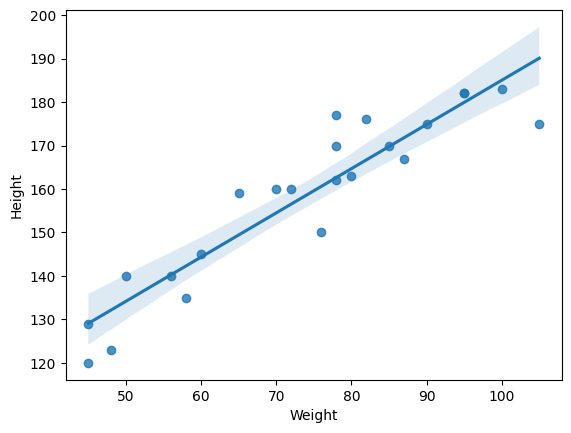

In [5]:
sns.regplot(y=df['Height'],x=df['Weight'])

In [6]:
df.isnull().sum()

Weight    0
Height    0
dtype: int64

In [8]:
df.shape

(23, 2)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  23 non-null     int64
 1   Height  23 non-null     int64
dtypes: int64(2)
memory usage: 500.0 bytes


In [10]:
df.describe()

,Weight,Height
count,23.000000,23.000000
mean,73.826087,158.391304
std,17.872407,19.511626
min,45.000000,120.000000
25%,59.000000,142.500000
50%,78.000000,162.000000
75%,86.000000,175.000000
max,105.000000,183.000000


<Axes: xlabel='Weight', ylabel='Height'>

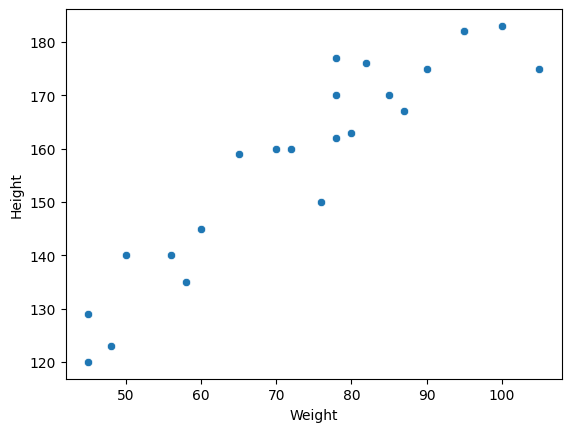

In [11]:
sns.scatterplot(x=df['Weight'],y=df['Height'])

<Axes: xlabel='Height'>

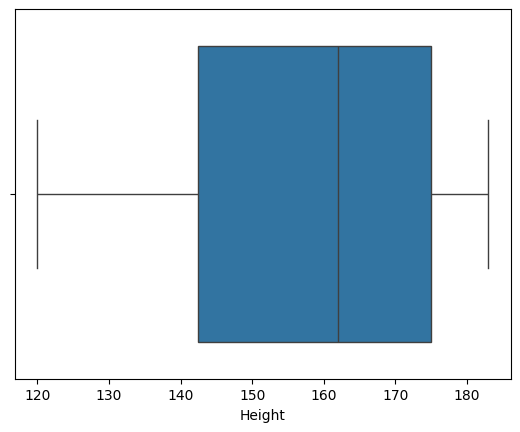

In [14]:
sns.boxplot(x=df['Height'])

<Axes: xlabel='Weight'>

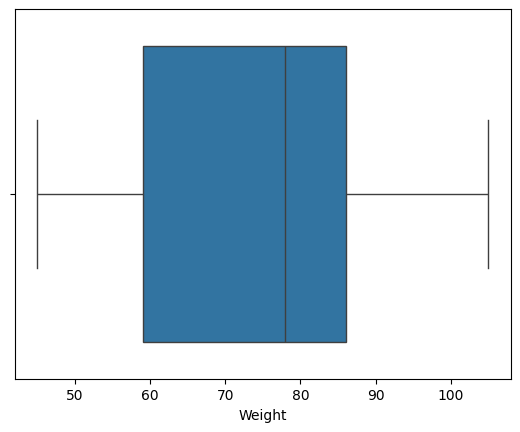

In [15]:
sns.boxplot(x=df['Weight'])

In [17]:
df.corr(method='pearson')

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


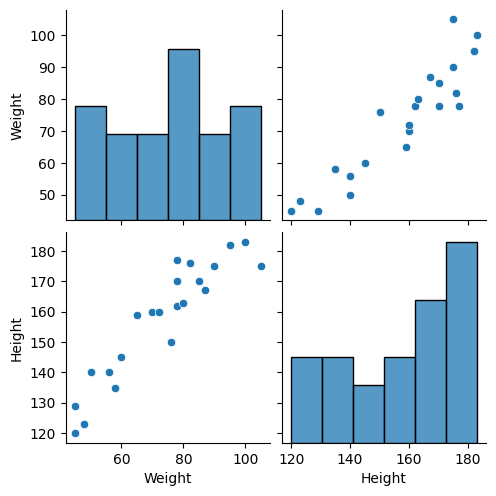

In [18]:
sns.pairplot(df)

In [ ]:
X=df[['Weight']] # the independent x must be in dataframe
y=df['Height']  #it can be in series or 1 d arr

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)


In [25]:
X_train

,Weight
1,58
13,100
5,78
2,48
11,95
20,45
3,60
4,70
18,76
16,50


In [27]:
X_test

,Weight
15,78
9,78
0,45
8,95
17,65
12,105


In [29]:
# standardization

from sklearn.preprocessing import StandardScaler

scalar=StandardScaler()

In [31]:
# in train just use fit_transform
scalar.fit_transform(X_train)

array([[-0.87662801],
       [ 1.66773133],
       [ 0.33497168],
       [-1.48242785],
       [ 1.36483141],
       [-1.6641678 ],
       [-0.75546804],
       [-0.1496682 ],
       [ 0.21381171],
       [-1.36126788],
       [-0.99778797],
       [-0.02850823],
       [ 1.06193149],
       [ 0.57729161],
       [ 0.75903157],
       [ 0.88019153],
       [ 0.45613165]])

In [32]:
# in test just use transform
#  if we use fit_transform then data leakage happens
scalar.transform(X_test)

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [36]:
# apply simple linear regression

from sklearn.linear_model import LinearRegression

regression=LinearRegression(n_jobs=-1)


In [37]:
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [38]:
regression.coef_

array([1.04792503])

In [39]:
regression.intercept_

np.float64(80.52684512622542)

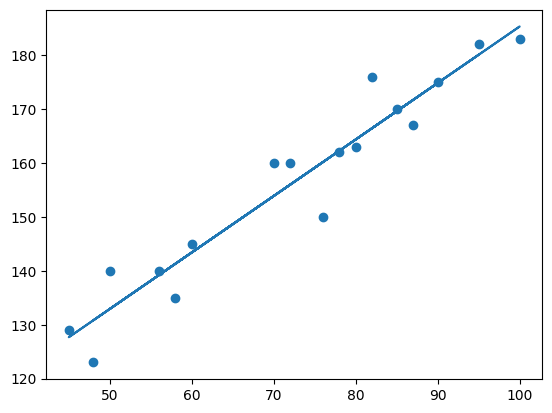

In [41]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))

In [45]:
# doing prediction

y_pred=regression.predict(X_test)

In [46]:
from sklearn.metrics import mean_absolute_error,mean_squared_error


In [48]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
mse,mae

(114.84069295228686, 9.665125886795005)

In [51]:
# r squares

from sklearn.metrics import r2_score

score=r2_score(y_test,y_pred)
score*100

73.6082671798128

In [52]:
# using ols
regression.predict([[37]])

d:\1-coding\python\1-turtule tutoriaal\tempgame\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([119.30007111])

In [57]:
regression.predict([[55]])

d:\1-coding\python\1-turtule tutoriaal\tempgame\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([138.16272159])